In [4]:

from generalizationhelper import run_experiments

default_env_config = {
  
    "num_quads": 2,              # Number of quads in the environment
    "episode_length": 2500,
    "target_start_ratio": 0.0,
    "obs_noise": 0.0,
    "policy_freq": 250.0,         # Policy frequency in Hz
    "sim_steps_per_action": 1,    # Physics steps between control actions
    "obs_noise": 0.0,             # Observation noise parameter
    "act_noise": 0.0,             # Actuator noise parameter
    "max_thrust_range": 0.15,     # Range for randomizing thrust
    "cable_length": 0.3,          # Cable length connecting payload to quads
    "trajectory": None,           # Default trajectory
    "payload_mass": 0.01,         # Mass of the payload
    "auto_reset": False,          # Auto-reset env on done
    "seed": 0,                   
    
}



def eval_generalization(parameter, values, default_env_config=default_env_config):
    config = default_env_config.copy()
    default_val = config[parameter]  # Store the default value

    for v in values:
        config[parameter] = v
        print(f"Running with {parameter}={v}")
        
        # Run the experiments with the modified config
        successful = run_experiments(
            num_envs=1000,
            env_config=config
        )

        rate = successful / 1000.0*100
        print(f"Success rate for {parameter}={v}: {rate:.2f}")
        # save as csv new line
        with open(f"results_generalization.csv", "a") as f:
            f.write(f"{parameter},{v},{rate:.2f},{default_val}\n")

In [5]:
import seaborn as sns
sns.set_theme(style="white", palette="muted", font_scale=0.8)

import mpl_fontkit as fk
# 1. Install and register Inter
fk.install("Inter")  
fk.set_font("Inter")  

import matplotlib.pyplot as plt

# # — Use TrueType embedding (requires matplotlib≥3.10.1):
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype']  = 42

# Set the default font size for all plots
plt.rcParams['font.size'] = 8

textwidth = 2*3.4127 # inches from 455,24411 pt textwidth in the document
# set default figure width to textwidth
plt.rcParams['figure.figsize'] = (textwidth, textwidth * 0.618)  # golden ratio
plt.rcParams['figure.dpi'] = 300  # high-quality output

color_array = sns.color_palette("muted", 10)

Font name: `Inter`


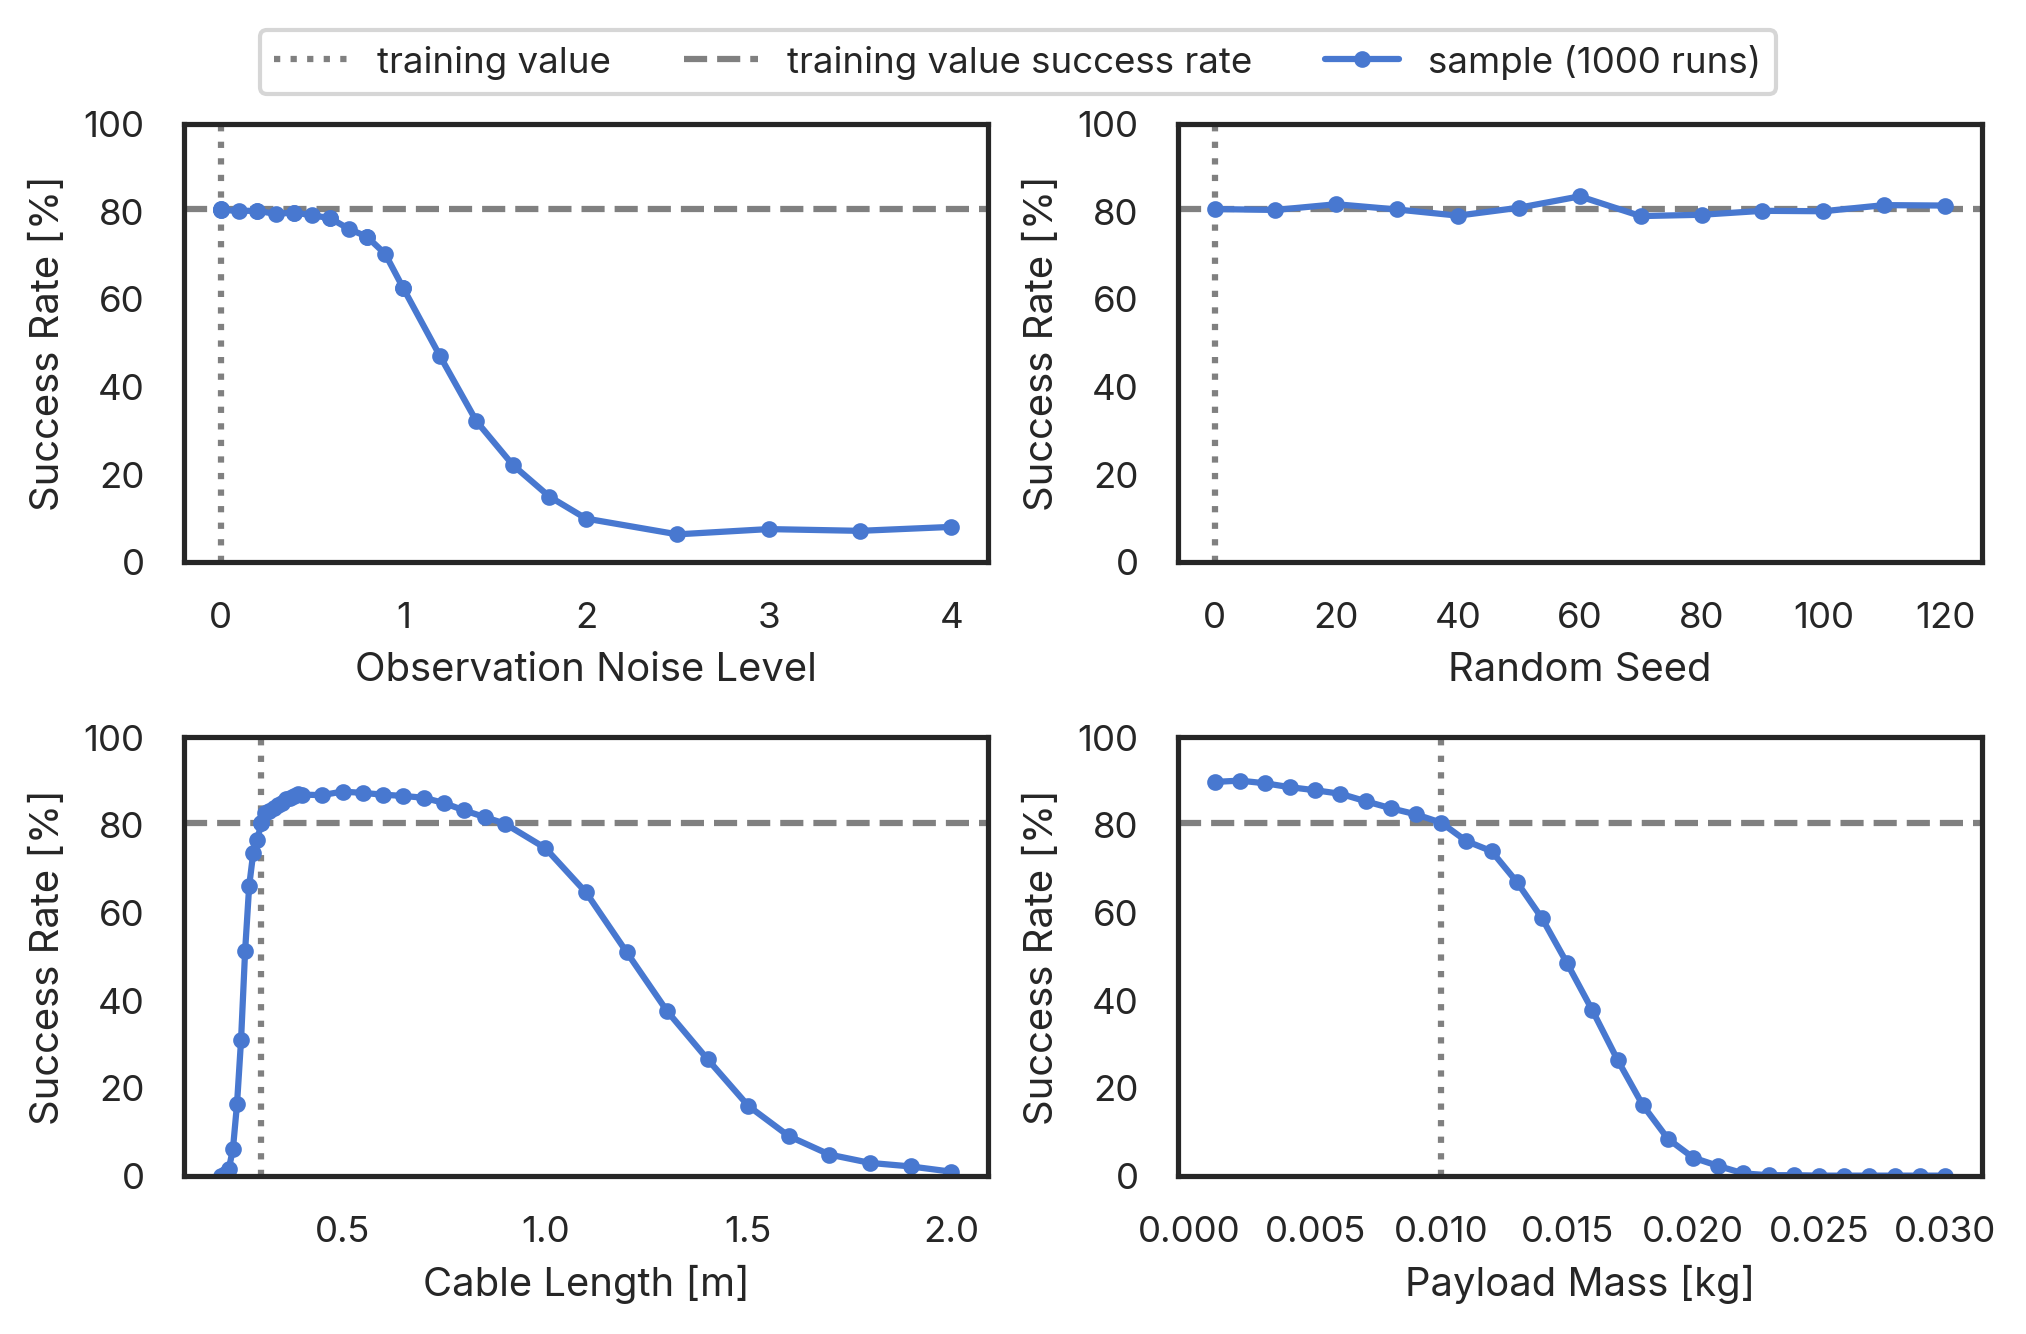

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from CSV
df = pd.read_csv('results_generalization.csv', sep=',')

# Parameters to plot
params = ['obs_noise', 'seed', 'cable_length', 'payload_mass']

# Create 2×2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(textwidth, textwidth * 0.618))
axes = axes.flatten()

# Plot each parameter
for ax, param in zip(axes, params):
    grp = df[df['parameter'] == param].sort_values('value')
    default_val = grp['default_value'].iloc[0]
    default_success = grp.loc[grp['value'] == default_val, 'success_rate'].mean()

 
    # vertical line at default value
    ax.axvline(default_val, color='gray', linestyle=':', label='training value')
    # horizontal line at default success rate
    ax.axhline(default_success, color='gray', linestyle='--', label='training value success rate')
    # plot data with markers
    ax.plot(grp['value'], grp['success_rate'], marker='o', linestyle='-', label='sample (1000 runs)', markersize=3)


    labels = param
    if param == 'obs_noise':
        labels = 'Observation Noise Level'
    elif param == 'seed':
        labels = 'Random Seed'
    elif param == 'cable_length':
        labels = 'Cable Length [m]'
    elif param == 'payload_mass':
        labels = 'Payload Mass [kg]'
    ax.set_xlabel(labels)
    ax.set_ylabel('Success Rate [%]')
    ax.set_ylim(0, 100)

# shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.05))

plt.tight_layout()

plt.savefig('generalization.pdf', bbox_inches='tight')


In [11]:
eval_generalization("obs_noise", [ 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0])

Running with obs_noise=0.6
Generating XML for 2 quadrotors with payload:
  Cable Length: 0.3 m
  Tendon Width: 0.001 m
  Payload Height: 1.5 m
  Payload Mass: 0.01 kg
  Frame Radius: 0.15 m
  Mesh Directory: jaxmarl/environments/mabrax/mujoco/assets
Using episode_length=2500 for multiquad_ix4
ENV IDS: {'quad_body_ids': [2, 4], 'quad_joint_ids': [1, 2], 'quad_qpos_starts': [7, 14], 'payload_body_id': 1, 'payload_joint_id': 0, 'payload_qpos_start': 0}
Running batched rollout with 1000 environments and 2 agents.
Observation dimension: 31


/opt/homebrew/Caskroom/miniconda/base/envs/quad-rl-mjx/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/opt/homebrew/Caskroom/miniconda/base/envs/quad-rl-mjx/lib/python3.10/site-packages/jax/_src/interpreters/xla.py:132: RuntimeWarning: overflow encountered in cast
  return np.asarray(x, dtypes.canonicalize_dtype(x.dtype))


Success rate for obs_noise=0.6: 78.40
Running with obs_noise=0.8
Generating XML for 2 quadrotors with payload:
  Cable Length: 0.3 m
  Tendon Width: 0.001 m
  Payload Height: 1.5 m
  Payload Mass: 0.01 kg
  Frame Radius: 0.15 m
  Mesh Directory: jaxmarl/environments/mabrax/mujoco/assets
Using episode_length=2500 for multiquad_ix4
ENV IDS: {'quad_body_ids': [2, 4], 'quad_joint_ids': [1, 2], 'quad_qpos_starts': [7, 14], 'payload_body_id': 1, 'payload_joint_id': 0, 'payload_qpos_start': 0}
Running batched rollout with 1000 environments and 2 agents.
Observation dimension: 31
Success rate for obs_noise=0.8: 74.20
Running with obs_noise=1.0
Generating XML for 2 quadrotors with payload:
  Cable Length: 0.3 m
  Tendon Width: 0.001 m
  Payload Height: 1.5 m
  Payload Mass: 0.01 kg
  Frame Radius: 0.15 m
  Mesh Directory: jaxmarl/environments/mabrax/mujoco/assets
Using episode_length=2500 for multiquad_ix4
ENV IDS: {'quad_body_ids': [2, 4], 'quad_joint_ids': [1, 2], 'quad_qpos_starts': [7, 14],